In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Param
C_D0 = 0.025
K_INDUCED = 0.045
W = 150
RHO = 1.225
S_WING = 1.0

Z_SW = 600.0
H_SW = 1000.0

GAMMA_MIN = np.deg2rad(-90.0)
GAMMA_MAX = np.deg2rad(-0.0)
DT = 0.5

In [3]:
# Best-Glider
CL_STAR = np.sqrt(C_D0 / K_INDUCED)
CD_STAR = C_D0 + K_INDUCED*CL_STAR**2
LD_MAX = CL_STAR/CD_STAR
GAMMA_STAR = -np.arctan2(1, LD_MAX)
V_STAR = np.sqrt(2*W*np.cos(abs(GAMMA_STAR)) / (RHO*S_WING*CL_STAR))

GAMMA_MAX = GAMMA_STAR

print(f'(L/D)_max = {LD_MAX:.4f}')
print(f'gamma* = {np.rad2deg(GAMMA_STAR):.4f}')
print(f'v* = {V_STAR:.4f}')

(L/D)_max = 14.9071
gamma* = -3.8378
v* = 18.1060


In [4]:
def glide_speed(gamma):
    gamma = float(np.clip(gamma, GAMMA_MIN, GAMMA_MAX))
    tan_g = np.tan(abs(gamma))
    disc = tan_g**2 - 4.0*K_INDUCED*C_D0
    CL = CL_STAR if disc < 0 else max(
        (tan_g - np.sqrt(disc)) / (2.0*K_INDUCED), 0.01
    )
    return float(np.sqrt(2*W*np.cos(abs(gamma)) / (RHO*S_WING*CL)))

In [5]:
def simulate_glide(gamma_fn, z_sw=Z_SW, h_sw=H_SW, dt=DT):
    if not callable(gamma_fn):
        gamma_val = float(gamma_fn)
        gamma_fn = lambda z, h: gamma_val

    t_arr, z_arr, h_arr, g_arr = [0.0], [z_sw], [h_sw], []

    t, z, h = 0.0, z_sw, h_sw
    while h > 1e-3:
        # gamma = float(np.clip(gamma_fn(z, h), GAMMA_MIN, GAMMA_MAX))
        gamma = np.clip(gamma_fn(z, h), GAMMA_MIN, GAMMA_MAX)
        v = glide_speed(gamma)
        g_arr.append(gamma)

        z += v*np.cos(abs(gamma))*dt
        h = max(h + v*np.sin(gamma)*dt, 0.0)
        t += dt

        t_arr.append(t)
        z_arr.append(z)
        h_arr.append(h)

    g_arr.append(gamma)

    return {
        't': np.array(t_arr),
        'z': np.array(z_arr),
        'h': np.array(h_arr),
        'gamma': np.array(g_arr),
    }

In [6]:
range_analytical = H_SW * LD_MAX
z_final_analytical = Z_SW + range_analytical

print('=== Analytical Max Range ===')
print(f'Analytical Range: {range_analytical:.2f}')
print(f'Final z: {z_final_analytical:.2f}')

# Simulated at constant gamma*
traj_analytial = simulate_glide(GAMMA_STAR)
range_simulated = traj_analytial['z'][-1] - Z_SW

print(f'Siulated range: {range_simulated:.2f}')
print(f'Error: {abs(range_simulated - range_analytical):.2f}')

=== Analytical Max Range ===
Analytical Range: 14907.12
Final z: 15507.12
Siulated range: 14913.01
Error: 5.89


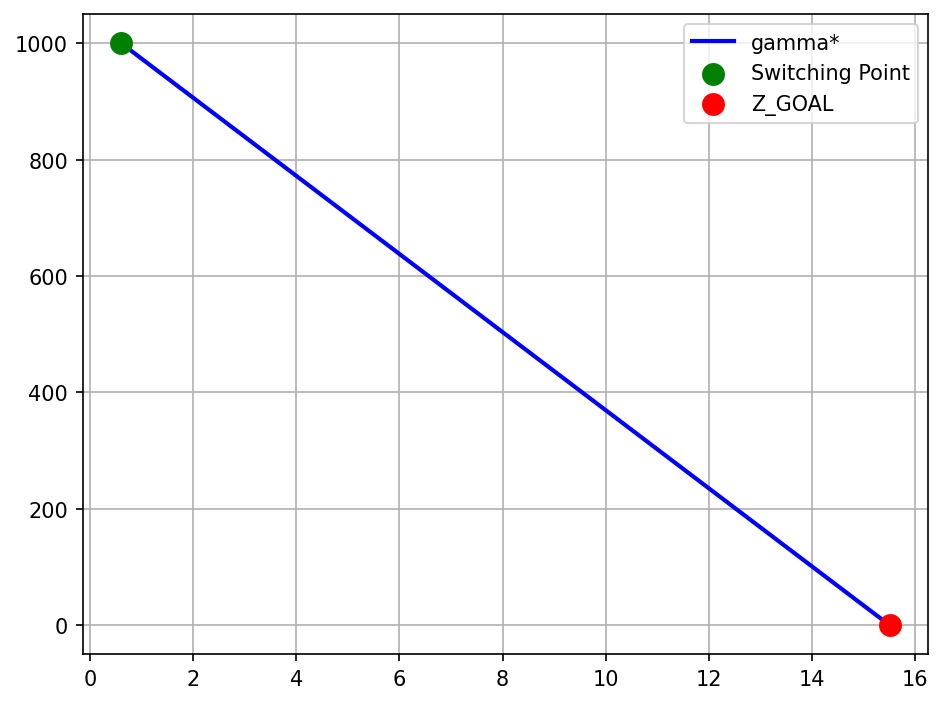

In [7]:
fig = plt.figure(dpi=150)
plt.plot(traj_analytial['z']/1000, traj_analytial['h'], 'b', lw=2, label=f'gamma*')
plt.scatter([Z_SW/1000], [H_SW], color='green', s=100, zorder=6, label=f'Switching Point')
plt.scatter([traj_analytial['z'][-1]/1000], [0], color='red', s=100, zorder=6, label=f'Z_GOAL')
plt.legend()
plt.grid()
plt.tight_layout()

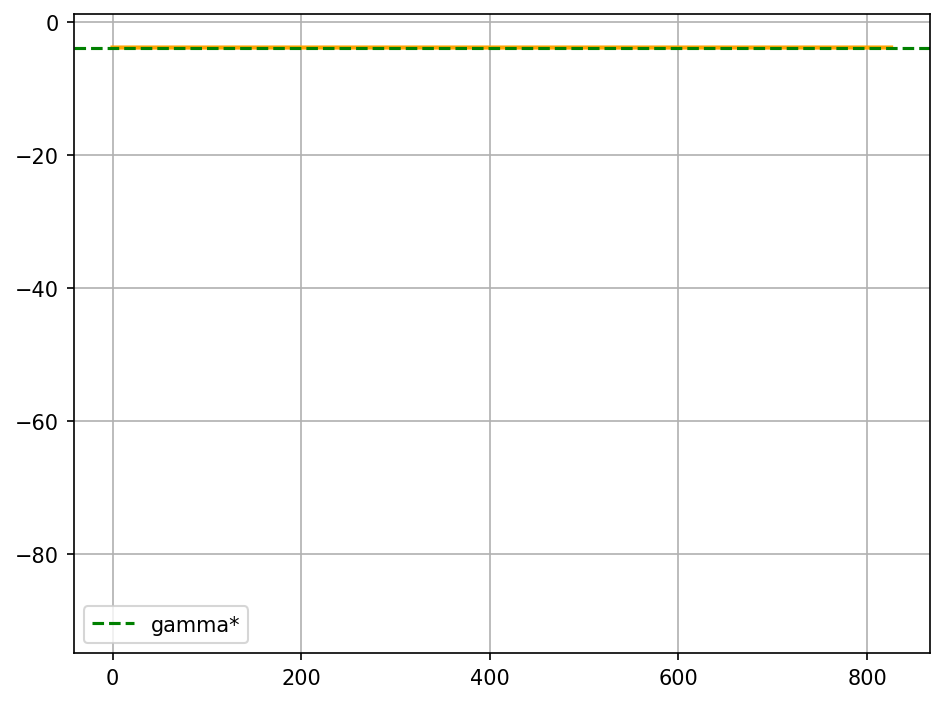

In [8]:
fig = plt.figure(dpi=150)
plt.plot(traj_analytial['t'], np.degrees(traj_analytial['gamma']), color='orange', lw=2)
plt.axhline(np.degrees(GAMMA_STAR), color='green', ls='--', lw=1.5, label=f'gamma*')
plt.ylim([np.rad2deg(GAMMA_MIN)-5, np.rad2deg(GAMMA_MAX)+5])
plt.legend()
plt.grid()
plt.tight_layout()

## Bellman Optimality

In [9]:
import casadi as ca
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize_scalar

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [10]:
Z_GOAL = 2000.0

In [11]:
# Cell 11: Grid setup -- V is 2D, gamma is control not state
N_Z     = 100
N_H     = 100
N_GAMMA = 10

z_grid     = np.linspace(Z_SW, Z_GOAL, N_Z)
h_grid     = np.linspace(0.0,  H_SW,   N_H)
gamma_grid = np.linspace(GAMMA_MIN, GAMMA_MAX, N_GAMMA)
# gamma_grid = np.sort(np.append(gamma_grid, np.radians(-45)))
gamma_straight = np.arctan2(0 - H_SW, Z_GOAL - Z_SW)
gamma_grid = np.sort(np.append(gamma_grid, gamma_straight))
print(f'Closest gamma in grid to -45: {np.degrees(gamma_grid[np.argmin(np.abs(gamma_grid - np.radians(-45)))]):.2f} deg')

dz = z_grid[1] - z_grid[0]
dh = h_grid[1] - h_grid[0]

# V is 2D -- (z, h) only. gamma is control.
INF = 1e9
V          = np.full((N_Z, N_H), INF)
gamma_star = np.full((N_Z, N_H), np.nan)

print(f'Grid:')
print(f'  z:     [{z_grid[0]:.0f}, {z_grid[-1]:.0f}] m   N_Z={N_Z},     dz={dz:.1f} m')
print(f'  h:     [{h_grid[0]:.0f}, {h_grid[-1]:.0f}] m   N_H={N_H},     dh={dh:.1f} m')
print(f'  gamma: [{np.degrees(gamma_grid[0]):.1f}, {np.degrees(gamma_grid[-1]):.1f}] deg   N_GAMMA={N_GAMMA}')
print(f'  V shape: {V.shape}  (2D, not 3D)')

Closest gamma in grid to -45: -42.13 deg
Grid:
  z:     [600, 2000] m   N_Z=100,     dz=14.1 m
  h:     [0, 1000] m   N_H=100,     dh=10.1 m
  gamma: [-90.0, -3.8] deg   N_GAMMA=10
  V shape: (100, 100)  (2D, not 3D)


In [12]:
# Cell 12: Precompute transitions for all gamma candidates
# dZ, dH, DS are (N_GAMMA,) -- one value per control candidate

V_glide = np.array([glide_speed(g) for g in gamma_grid])   # airspeed at each gamma

dZ = V_glide * np.cos(gamma_grid) * DT    # horizontal advance per step
dH = V_glide * np.sin(gamma_grid) * DT    # altitude change per step (negative)
DS = V_glide * DT                          # path length cost per step

print(f'Precomputed transitions for {N_GAMMA} gamma candidates:')
print(f'  dZ range: [{dZ.min():.2f}, {dZ.max():.2f}] m/step')
print(f'  dH range: [{dH.min():.2f}, {dH.max():.2f}] m/step')
print(f'  DS range: [{DS.min():.2f}, {DS.max():.2f}] m/step')

Precomputed transitions for 10 gamma candidates:
  dZ range: [0.00, 30.67] m/step
  dH range: [-42.33, -0.00] m/step
  DS range: [0.00, 46.34] m/step


In [13]:
cost = np.zeros((N_Z, N_H))

for i_z in range(N_Z):
    for i_h in range(N_H):
        cost[i_z, i_h] = np.sqrt((z_grid[i_z] - Z_GOAL)**2 + (h_grid[i_h] - 0.0)**2)

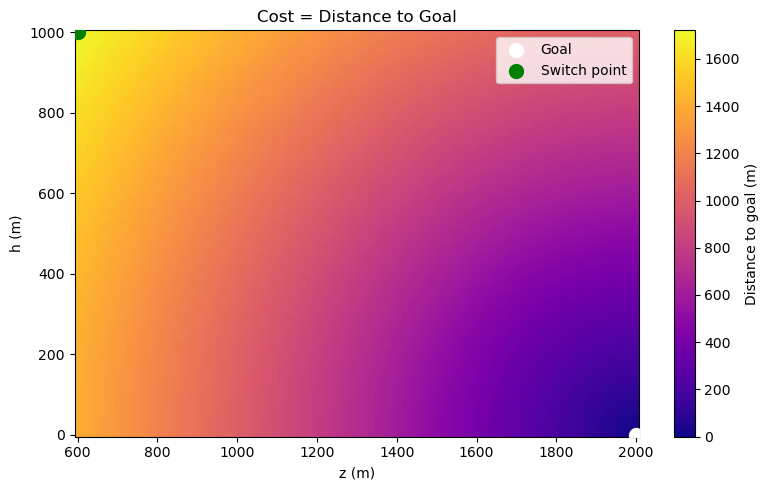

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.pcolormesh(z_grid, h_grid, cost.T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='Distance to goal (m)')
ax.scatter([Z_GOAL], [0], color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW], [H_SW], color='green', s=100, zorder=5, label='Switch point')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title('Cost = Distance to Goal')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
gamma_straight = np.arctan2(0 - H_SW, Z_GOAL - Z_SW)
print(f'Straight line angle: {np.degrees(gamma_straight):.2f} deg')
print(f'GAMMA_MIN: {np.degrees(GAMMA_MIN):.2f} deg')
print(f'GAMMA_MAX (best glide): {np.degrees(GAMMA_MAX):.2f} deg')
print(f'Feasible: {GAMMA_MIN <= gamma_straight <= GAMMA_MAX}')

Straight line angle: -35.54 deg
GAMMA_MIN: -90.00 deg
GAMMA_MAX (best glide): -3.84 deg
Feasible: True


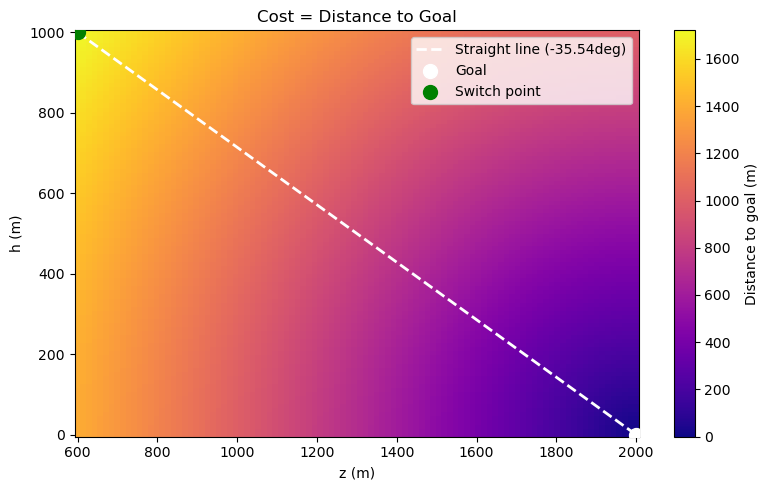

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.pcolormesh(z_grid, h_grid, cost.T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='Distance to goal (m)')

# Straight line from switch point to goal
z_line = np.array([Z_SW, Z_GOAL])
h_line = np.array([H_SW, 0.0])
ax.plot(z_line, h_line, 'w--', lw=2, label=f'Straight line ({np.degrees(gamma_straight):.2f}deg)')

ax.scatter([Z_GOAL], [0],    color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW],   [H_SW], color='green', s=100, zorder=5, label='Switch point')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title('Cost = Distance to Goal')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
V = np.full((N_Z, N_H), INF)

# Terminal condition: V = 0 at goal
i_z_goal = np.argmin(np.abs(z_grid - Z_GOAL))
i_h_goal = np.argmin(np.abs(h_grid - 0.0))
V[i_z_goal, i_h_goal] = 0.0

print(f'V initialized: {np.sum(V < INF)} nodes with finite value')
print(f'Goal node: iz={i_z_goal}, ih={i_h_goal}, z={z_grid[i_z_goal]:.1f}, h={h_grid[i_h_goal]:.1f}')

V initialized: 1 nodes with finite value
Goal node: iz=99, ih=0, z=2000.0, h=0.0


In [18]:
print(gamma_grid)

[-1.57079633 -1.40370581 -1.2366153  -1.06952478 -0.90243426 -0.73534375
 -0.62024949 -0.56825323 -0.40116272 -0.2340722  -0.06698169]


In [19]:
CONVERGED = False

dz = z_grid[1] - z_grid[0]
DT = dz / (glide_speed(gamma_straight) * np.cos(abs(gamma_straight)))
print(f'New DT: {DT:.4f}')

while not CONVERGED:
    V_old = V.copy()
    for iz in range(N_Z):
        for ih in range(N_H):
            for igamma in range(len(gamma_grid)):
                # At grid (iz, ih, igamma):
                # Where do we end up if we apply gamma from (iz, ih)?
                z = z_grid[iz]
                h = h_grid[ih]
                gamma = gamma_grid[igamma]

                # Vehicle dynamics
                z_next = z + glide_speed(gamma) * np.cos(gamma) * DT
                h_next = h + glide_speed(gamma) * np.sin(gamma) * DT

                # Look up value at successor
                iz_next = np.argmin(np.abs(z_grid - z_next))
                ih_next = np.argmin(np.abs(h_grid - h_next))
                V_next = V[iz_next, ih_next]

                # Bellman update
                candidate = cost[iz, ih] + V_next

                # keep best gamma
                if candidate < V[iz, ih]:
                    V[iz, ih] = candidate
                    gamma_star[iz, ih] = gamma

    delta = np.max(np.abs(V - V_old))
    if delta < 0.1:
        CONVERGED = True

New DT: 0.2306


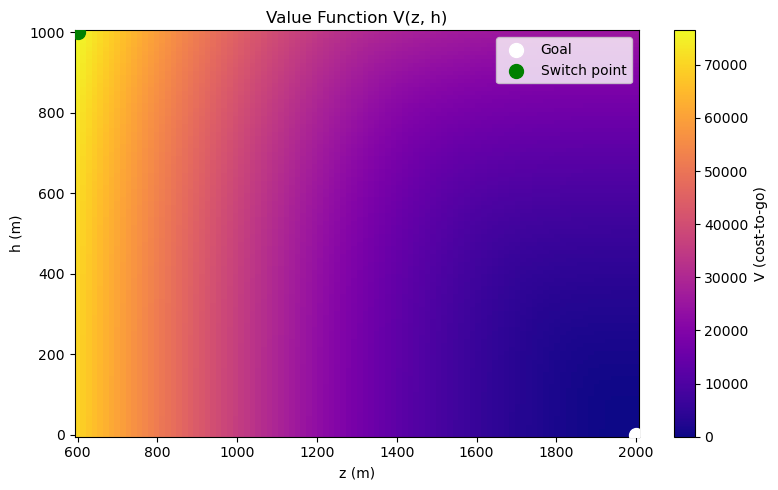

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.pcolormesh(z_grid, h_grid, V.T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='V (cost-to-go)')
ax.scatter([Z_GOAL], [0],    color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW],   [H_SW], color='green', s=100, zorder=5, label='Switch point')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title('Value Function V(z, h)')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
z, h = Z_SW, H_SW
z_traj, h_traj = [z], [h]
max_steps = N_Z * N_H  # upper bound

for step in range(max_steps):
    if np.sqrt((z - Z_GOAL)**2 + (h - 0.0)**2) < 10.0:
        print(f'Reached goal at step {step}')
        break
    
    iz = np.argmin(np.abs(z_grid - z))
    ih = np.argmin(np.abs(h_grid - h))
    
    best_val = INF
    best_z   = z
    best_h   = h
    
    for gamma in gamma_grid:
        v      = glide_speed(gamma)
        z_next = z + v * np.cos(gamma) * DT
        h_next = h + v * np.sin(gamma) * DT
        
        iz_next = np.argmin(np.abs(z_grid - z_next))
        ih_next = np.argmin(np.abs(h_grid - h_next))
        
        if V[iz_next, ih_next] < best_val:
            best_val = V[iz_next, ih_next]
            best_z   = z_next
            best_h   = h_next
    
    z, h = best_z, best_h
    # h = max(h, 0.0)
    z_traj.append(z)
    h_traj.append(h)

    if h <= 0.0:
        print(f'Hit ground at step {step}')
        break
else:
    print(f'Max steps reached: {max_steps}')

print(f'Trajectory: {len(z_traj)} steps')
print(f'Start: z={z_traj[0]:.1f}m, h={h_traj[0]:.1f}m')
print(f'End:   z={z_traj[-1]:.1f}m, h={h_traj[-1]:.1f}m')

Hit ground at step 96
Trajectory: 98 steps
Start: z=600.0m, h=1000.0m
End:   z=1964.8m, h=-6.3m


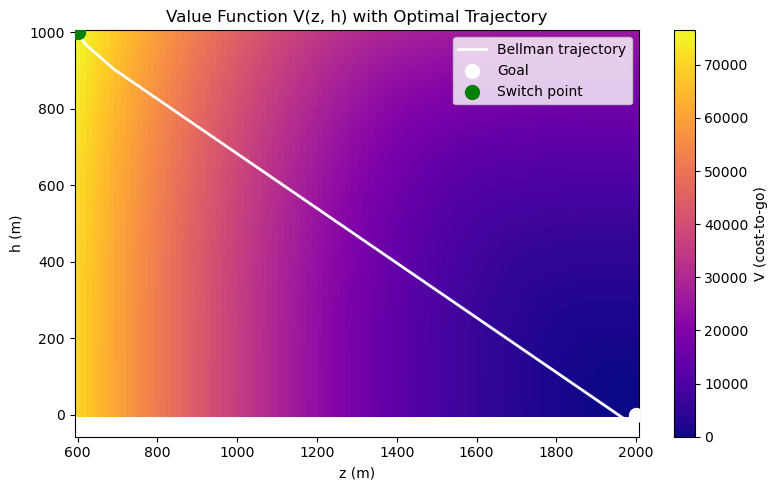

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.pcolormesh(z_grid, h_grid, V.T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='V (cost-to-go)')

ax.plot(z_traj, h_traj, 'w-', lw=2, label='Bellman trajectory')

ax.scatter([Z_GOAL], [0],    color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW],   [H_SW], color='green', s=100, zorder=5, label='Switch point')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title('Value Function V(z, h) with Optimal Trajectory')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
gamma_traj = np.arctan2(np.diff(h_traj), np.diff(z_traj))

print(f'gamma along trajectory (deg): {np.degrees(gamma_traj)}')
print(f'mean gamma: {np.degrees(np.mean(gamma_traj)):.2f} deg')
print(f'Analytical gamma: {np.degrees(gamma_straight):.2f} deg')

gamma along trajectory (deg): [-61.27925599 -51.70567466 -42.13209332 -42.13209332 -42.13209332
 -42.13209332 -42.13209332 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53767779 -35.53767779
 -35.53767779 -35.53767779 -35.53767779 -35.53

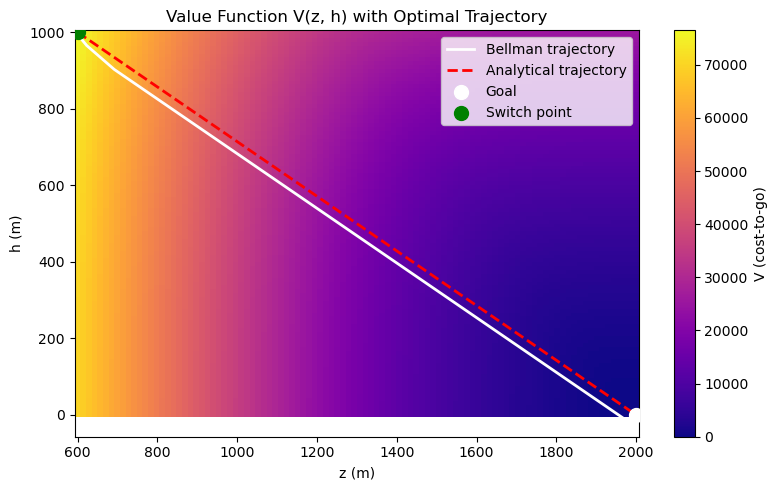

In [24]:
# Analytical trajectory: straight line from switch point to goal
z_analytical = np.linspace(Z_SW, Z_GOAL, 100)
h_analytical = np.linspace(H_SW, 0.0, 100)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(z_grid, h_grid, V.T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='V (cost-to-go)')

ax.plot(z_traj,       h_traj,       'w-',  lw=2, label='Bellman trajectory')
ax.plot(z_analytical, h_analytical, 'r--', lw=2, label='Analytical trajectory')

ax.scatter([Z_GOAL], [0],    color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW],   [H_SW], color='green', s=100, zorder=5, label='Switch point')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title('Value Function V(z, h) with Optimal Trajectory')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
print(f'gamma along traj: mean={np.degrees(np.mean(gamma_traj)):.2f}, std={np.degrees(np.std(gamma_traj)):.2f}')
print(f'gamma_straight: {np.degrees(gamma_straight):.2f} deg')
print(f'Traj end: z={z_traj[-1]:.2f}, h={h_traj[-1]:.2f}')

gamma along traj: mean=-36.31, std=3.34
gamma_straight: -35.54 deg
Traj end: z=1964.78, h=-6.34


# Adding Radar: RCS

In [26]:
def aspect_angle(z, h, z_radar, gamma, h_radar=0):
    # Aspect rangle between radar LOS to aircraft to ground level
    # Assume aircraft is NED

    # angle from aircraft to radar
    los_angle = np.arctan2(h_radar-h, z_radar-z)

    # Vehicle nose points in direction of gamma
    nose_angle = gamma

    # Aspect angle
    alpha = los_angle - nose_angle

    # Wrap in [-pi, pi]
    alpha = (alpha+np.pi)%(2*np.pi) - np.pi
    return alpha

In [27]:
def rcs(alpha, sigma_0=1.0, sigma_min=0.1):
    # RCS model
    return sigma_min + (sigma_0 - sigma_min) * np.cos(alpha - np.pi/2)**2

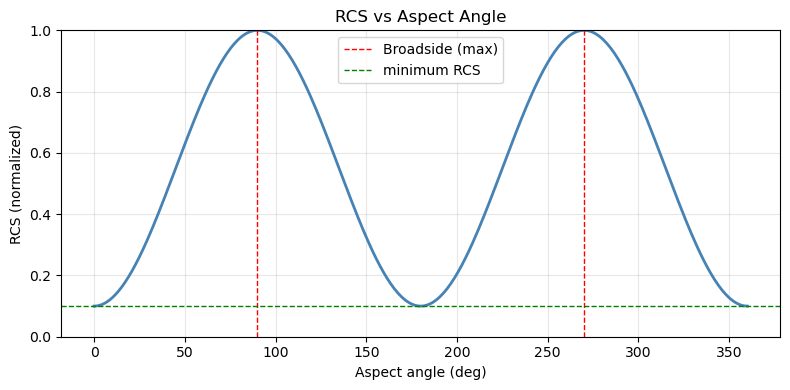

In [28]:
alpha_arr = np.linspace(0, 2*np.pi, 360)
rcs_arr   = rcs(alpha_arr)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(alpha_arr), rcs_arr, 'steelblue', lw=2)
ax.axvline(90,  color='r', ls='--', lw=1, label='Broadside (max)')
ax.axvline(270, color='r', ls='--', lw=1)
ax.axhline(0.1, color='g', ls='--', lw=1, label='minimum RCS')
ax.set_ylim(0, 1.0)
ax.set_xlabel('Aspect angle (deg)')
ax.set_ylabel('RCS (normalized)')
ax.set_title('RCS vs Aspect Angle')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
def range_to_radar(z, h, z_radar, h_radar):
    # Distance to radar
    return np.sqrt((z - z_radar)**2 + (h - h_radar)**2)

In [30]:
def detection_prob(z, h, gamma, z_radar, h_radar, lambda_val=1.0):
    """
    Poisson detection probability based on RCS and range.
    P_D = 1 - exp(-lambda * sigma(alpha) / r^4)
    """
    r     = range_to_radar(z, h, z_radar, h_radar)
    alpha = aspect_angle(z, h, z_radar, h_radar, gamma)
    sigma = rcs(alpha)
    return 1 - np.exp(-lambda_val * sigma / r**4)

In [31]:
lambda_val = 5e10

z_radar, h_radar = 1800.0, 0.0

print('Case 1: close, broadside')
print(f'  P_D = {detection_prob(900.0, 100.0, np.radians(-90), z_radar, h_radar, lambda_val):.4f}')

print('Case 2: far, broadside')
print(f'  P_D = {detection_prob(600.0, 100.0, np.radians(-90), z_radar, h_radar, lambda_val):.4f}')

print('Case 3: close, nose-on')
print(f'  P_D = {detection_prob(800.0, 0.0, np.radians(0), z_radar, h_radar, lambda_val):.4f}')

print('Case 4: very far')
print(f'  P_D = {detection_prob(400.0, 500.0, np.radians(-45), z_radar, h_radar, lambda_val):.4f}')

Case 1: close, broadside
  P_D = 0.0082
Case 2: far, broadside
  P_D = 0.0025
Case 3: close, nose-on
  P_D = 0.0050
Case 4: very far
  P_D = 0.0021


In [46]:
alpha_1 = 0.75
alpha_2 = 1-alpha_1

# Precompute raw terms
pd_raw   = np.zeros((N_Z, N_H, len(gamma_grid)))
dist_raw = np.zeros((N_Z, N_H))

for i_z in range(N_Z):
    for i_h in range(N_H):
        dist_raw[i_z, i_h] = np.sqrt((z_grid[i_z] - Z_GOAL)**2 + (h_grid[i_h] - 0.0)**2)
        for i_g in range(len(gamma_grid)):
            pd_raw[i_z, i_h, i_g] = detection_prob(z_grid[i_z], h_grid[i_h], gamma_grid[i_g], z_radar, h_radar, lambda_val)

# Normalize each to [0, 1]
pd_norm   = (pd_raw   - pd_raw.min())   / (pd_raw.max()   - pd_raw.min())
dist_norm = (dist_raw - dist_raw.min()) / (dist_raw.max() - dist_raw.min())

# Combine
cost = alpha_1 * pd_norm + alpha_2 * dist_norm[:, :, None]

print(f'cost shape: {cost.shape}')
print(f'cost range: [{cost.min():.4f}, {cost.max():.4f}]')

cost shape: (100, 100, 11)
cost range: [0.1423, 0.8101]


In [47]:
print(f'pd_norm   range: [{pd_norm.min():.4f}, {pd_norm.max():.4f}]')
print(f'dist_norm range: [{dist_norm.min():.4f}, {dist_norm.max():.4f}]')

pd_norm   range: [0.0000, 1.0000]
dist_norm range: [0.0000, 1.0000]


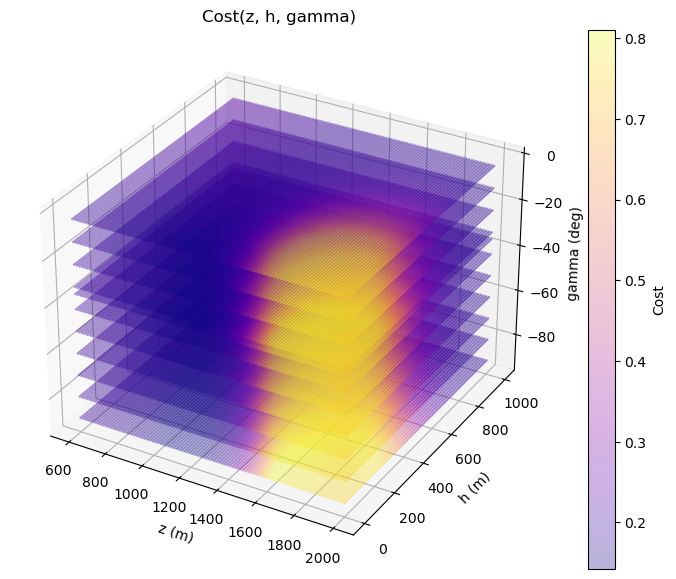

In [48]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

Z_mesh, H_mesh, G_mesh = np.meshgrid(z_grid, h_grid, np.degrees(gamma_grid), indexing='ij')

sc = ax.scatter(
    Z_mesh.flatten(),
    H_mesh.flatten(),
    G_mesh.flatten(),
    c=cost.flatten(),
    cmap='plasma',
    alpha=0.3,
    s=1
)

plt.colorbar(sc, label='Cost')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_zlabel('gamma (deg)')
ax.set_title('Cost(z, h, gamma)')
plt.show()

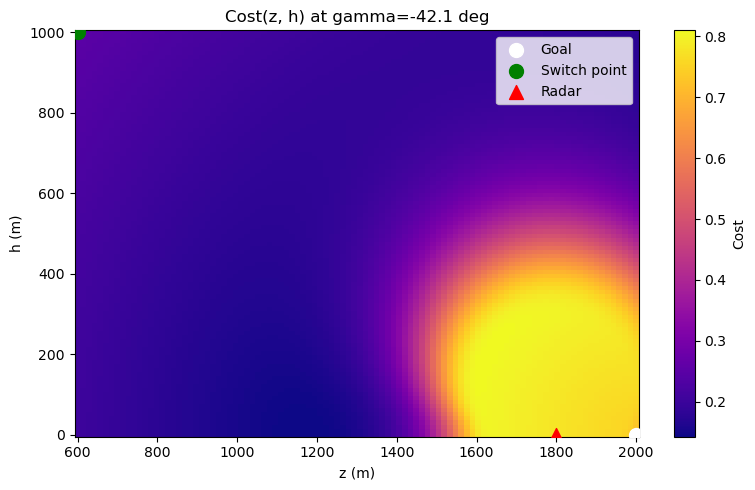

In [49]:
ig = len(gamma_grid) // 2   # pick middle gamma

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(z_grid, h_grid, cost[:, :, ig].T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='Cost')
ax.scatter([Z_GOAL],  [0],       color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW],    [H_SW],    color='green', s=100, zorder=5, label='Switch point')
ax.scatter([z_radar], [h_radar], color='red',   s=100, zorder=5, marker='^', label='Radar')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title(f'Cost(z, h) at gamma={np.degrees(gamma_grid[ig]):.1f} deg')
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
# Reinitialize V and gamma_star
V          = np.full((N_Z, N_H), INF)
gamma_star = np.full((N_Z, N_H), np.nan)

# Goal node
i_z_goal = np.argmin(np.abs(z_grid - Z_GOAL))
i_h_goal = np.argmin(np.abs(h_grid - 0.0))
V[i_z_goal, i_h_goal] = 0.0

CONVERGED = False
while not CONVERGED:
    V_old = V.copy()
    for iz in range(N_Z):
        for ih in range(N_H):
            for igamma in range(len(gamma_grid)):
                z     = z_grid[iz]
                h     = h_grid[ih]
                gamma = gamma_grid[igamma]

                z_next = z + glide_speed(gamma) * np.cos(gamma) * DT
                h_next = h + glide_speed(gamma) * np.sin(gamma) * DT

                iz_next = np.argmin(np.abs(z_grid - z_next))
                ih_next = np.argmin(np.abs(h_grid - h_next))
                V_next  = V[iz_next, ih_next]

                candidate = cost[iz, ih, igamma] + V_next
                if candidate < V[iz, ih]:
                    V[iz, ih]          = candidate
                    gamma_star[iz, ih] = gamma

    delta = np.max(np.abs(V - V_old))
    if delta < 0.1:
        CONVERGED = True

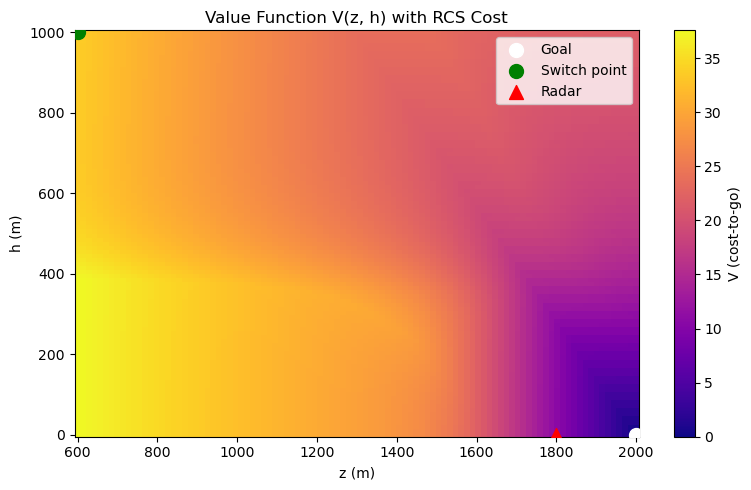

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(z_grid, h_grid, V.T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='V (cost-to-go)')

ax.scatter([Z_GOAL],  [0],       color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW],    [H_SW],    color='green', s=100, zorder=5, label='Switch point')
ax.scatter([z_radar], [h_radar], color='red',   s=100, zorder=5, marker='^', label='Radar')

ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title('Value Function V(z, h) with RCS Cost')
ax.legend()
plt.tight_layout()
plt.show()

In [57]:
z, h = Z_GOAL, 0.0
z_traj, h_traj = [z], [h]
max_steps = N_Z * N_H

for step in range(max_steps):
    if np.sqrt((z - Z_SW)**2 + (h - H_SW)**2) < 10.0:
        print(f'Reached switch point at step {step}')
        break

    iz = np.argmin(np.abs(z_grid - z))
    ih = np.argmin(np.abs(h_grid - h))

    # Check all adjacent grid nodes
    best_val = INF
    best_iz  = iz
    best_ih  = ih

    for diz, dih in [(-1, 0), (0, 1), (-1, 1)]:
        iz_next = iz + diz
        ih_next = ih + dih
        if 0 <= iz_next < N_Z and 0 <= ih_next < N_H:
            if V[iz_next, ih_next] < best_val:
                best_val = V[iz_next, ih_next]
                best_iz  = iz_next
                best_ih  = ih_next

    z = z_grid[best_iz]
    h = h_grid[best_ih]
    z_traj.append(z)
    h_traj.append(h)

else:
    print(f'Max steps reached: {max_steps}')

print(f'Trajectory: {len(z_traj)} steps')
print(f'Start: z={z_traj[0]:.1f}m, h={h_traj[0]:.1f}m')
print(f'End:   z={z_traj[-1]:.1f}m, h={h_traj[-1]:.1f}m')

Reached switch point at step 177
Trajectory: 178 steps
Start: z=2000.0m, h=0.0m
End:   z=600.0m, h=1000.0m


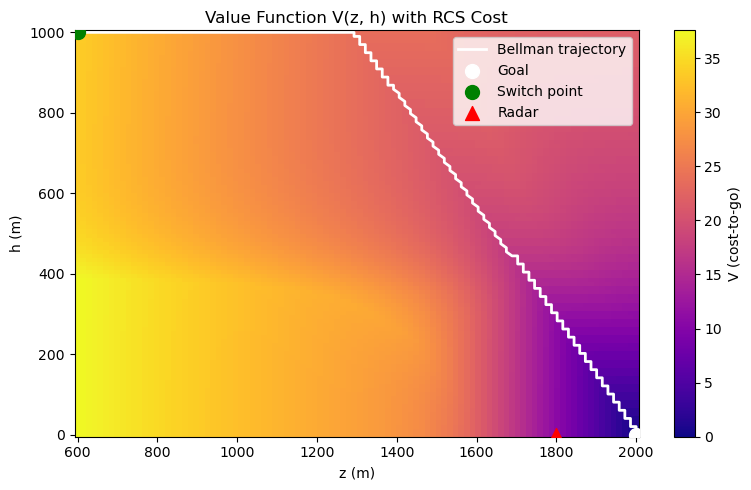

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(z_grid, h_grid, V.T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='V (cost-to-go)')

ax.plot(z_traj, h_traj, 'w-', lw=2, label='Bellman trajectory')

ax.scatter([Z_GOAL],  [0],       color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW],    [H_SW],    color='green', s=100, zorder=5, label='Switch point')
ax.scatter([z_radar], [h_radar], color='red',   s=100, zorder=5, marker='^', label='Radar')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title('Value Function V(z, h) with RCS Cost')
ax.legend()
plt.tight_layout()
plt.show()

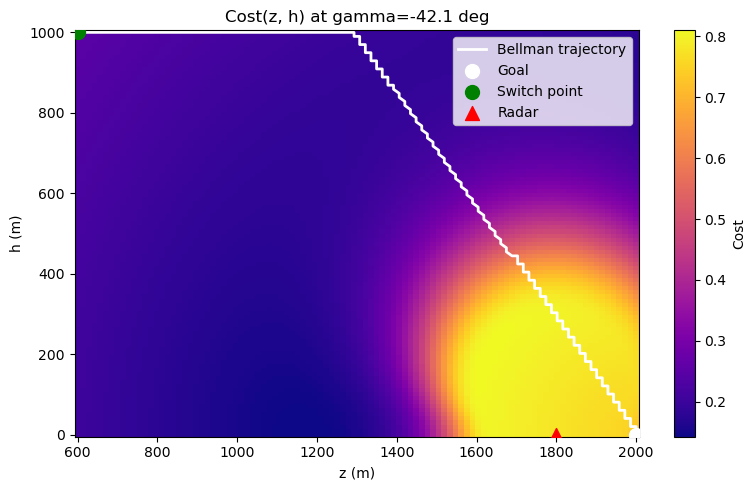

In [67]:
ig = len(gamma_grid) // 2   # pick middle gamma

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(z_grid, h_grid, cost[:, :, ig].T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax, label='Cost')
ax.plot(z_traj, h_traj, 'w-', lw=2, label='Bellman trajectory')
ax.scatter([Z_GOAL],  [0],       color='white', s=100, zorder=5, label='Goal')
ax.scatter([Z_SW],    [H_SW],    color='green', s=100, zorder=5, label='Switch point')
ax.scatter([z_radar], [h_radar], color='red',   s=100, zorder=5, marker='^', label='Radar')
ax.set_xlabel('z (m)')
ax.set_ylabel('h (m)')
ax.set_title(f'Cost(z, h) at gamma={np.degrees(gamma_grid[ig]):.1f} deg')
ax.legend()
plt.tight_layout()
plt.show()